# IC-02 — Exploratory Data Analysis, corporate credit rating

**ML & FinTech · 115-1 · 20260914**

Two parts, 15 minutes each. You may use any AI tool you like — that is the point.
What is being graded is your **judgement**, not your syntax.

Submit this notebook, run, to your own repository as `IC-02.ipynb`.

---
**A note before you start.** Every question below has an answer an AI will give you
in one shot. Some of those answers are wrong. Your job is to find out which.

## The codebook

Dataset: `corporate-credit-rating-with-financial-ratios` (kirtandelwadia, via `kagglehub`). One row is one
**rating event** — a rating agency's assessment of one corporation on one date, not one row per company.

| Column | Meaning | Documented values |
|---|---|---|
| `Rating Agency` | agency issuing the rating (e.g. S&P, Moody's) | 7 agencies |
| `Corporation` / `Ticker` / `CIK` | company identity, not a feature | text / text / SEC filer id |
| `Rating` | letter credit rating | `AAA` … `D`, 23 grades |
| `Rating Date` | date of the rating | 2010-04-06 to 2016-12-27 |
| `Binary Rating` | simplified label | 1 = investment grade (BBB- or better), 0 = speculative grade |
| `SIC Code` / `Sector` | industry code / industry group | numeric code / 12 sectors |
| 16 remaining columns | financial ratios | e.g. `Current Ratio`, `Debt/Equity Ratio`, `ROE`, `ROA`, margins, cash-flow-per-share |

## Setup

Run this first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CANDIDATES = [
    "corporateCreditRatingWithFinancialRatios.csv",
    "../data/corporateCreditRatingWithFinancialRatios.csv",
    "data/corporateCreditRatingWithFinancialRatios.csv",
]
path = next((p for p in CANDIDATES if Path(p).exists()), None)

if path is None:
    # Not found locally — fetch it (public dataset, no Kaggle API key needed).
    try:
        import kagglehub
    except ImportError:
        %pip install -q kagglehub
        import kagglehub
    download_dir = kagglehub.dataset_download(
        "kirtandelwadia/corporate-credit-rating-with-financial-ratios"
    )
    path = str(Path(download_dir) / "corporateCreditRatingWithFinancialRatios.csv")

df = pd.read_csv(path)
print(path, df.shape)
df.head()

C:\Users\paul9\.cache\kagglehub\datasets\kirtandelwadia\corporate-credit-rating-with-financial-ratios\versions\1\corporateCreditRatingWithFinancialRatios.csv (7805, 25)


,Rating Agency,Corporation,Rating,Rating Date,CIK,Binary Rating,SIC Code,Sector,Ticker,Current Ratio,...,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,1056903,1,4941.0,Utils,AWR,1.1507,...,28.9834,13.6093,8.3224,0.3173,8.1724,8.1978,2.6385,4.4530,1.9957,-0.1333
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,...,23.9379,20.8699,13.5690,0.3324,22.0354,47.2858,4.4944,21.8765,0.2501,0.3132
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,8858,1,5065.0,Shops,AVT,1.9276,...,3.6338,3.0536,2.1418,2.4620,13.6376,16.7991,5.2731,9.6494,-7.6079,-7.3231
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,1035201,1,4941.0,Utils,CWT,0.8358,...,27.9377,15.1135,9.0246,0.2946,9.6412,9.7015,2.6583,5.1018,1.7438,-0.8999
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,721371,1,5122.0,Shops,CAH,1.2931,...,1.5847,1.2304,0.6518,4.9276,11.1256,19.4184,2.9364,8.1844,1.9725,2.4174


---
# Part A — Do you believe this number? (15 min)

### A1

The cell below ranks every numeric column by skewness. It reports `Long-term Debt / Capital`
as the most skewed variable, at roughly **21.6** — an extreme value for a ratio that is usually
somewhere between 0 and 1.

**Do you believe it? Answer Yes or No, and show your evidence in code.**

In [2]:
df.select_dtypes(include="number").skew().sort_values(ascending=False).head(5).round(2)

Long-term Debt / Capital         21.60
Operating Cash Flow Per Share    13.54
Return On Tangible Equity         8.95
Current Ratio                     7.26
Asset Turnover                    2.77
dtype: float64

In [3]:
# A1 — evidence: who is actually driving this number?
col = "Long-term Debt / Capital"
print(df[col].describe())
print("5 largest:", df[col].nlargest(5).tolist())
print("5 smallest:", df[col].nsmallest(5).tolist())

count    7805.000000
mean        0.452804
std         2.629158
min       -86.363600
25%         0.286500
50%         0.427200
75%         0.542200
max       171.500000
Name: Long-term Debt / Capital, dtype: float64
5 largest: [171.5, 17.3667, 17.3667, 17.3667, 17.3667]
5 smallest: [-86.3636, -86.3636, -86.3636, -7.443, -1.7228]


**A1 answer (Yes / No, plus one sentence):**

> **Yes, the arithmetic is correct — but no, it isn't telling you "most companies are highly
> leveraged."** The 5 largest values are one company at 171.5 plus **four identical copies of
> 17.3667** — the same corporation rated on four different dates — and the smallest values repeat
> **-86.3636 three times** the same way; a handful of over-sampled companies, not the typical firm,
> are generating this skew.

### A2

Compare the data against the codebook above.

**Find TWO places where the data disagrees with the documentation.** Show the evidence in code.

In [4]:
# A2.1 — is each row really one company, as a "predict rating from ratios" framing implies?
dup_counts = df["Corporation"].value_counts()
print("unique corporations:", df["Corporation"].nunique(), "/ total rows:", len(df))
print("corporations appearing more than once:", (dup_counts > 1).sum())
print(dup_counts.head(5))

unique corporations: 1377 / total rows: 7805
corporations appearing more than once: 1165
Corporation
Mondelez International, Inc.    23
Tenet Healthcare Corp.          23
TransDigm Inc.                  23
Duke Energy Corporation         22
POSCO                           21
Name: count, dtype: int64


In [5]:
# A2.2 — Debt/Equity Ratio range is never stated, but is it plausible?
print(df["Debt/Equity Ratio"].describe()[["min", "25%", "50%", "75%", "max"]])

min   -1473.0980
25%       0.4197
50%       0.7528
75%       1.2116
max     194.3750
Name: Debt/Equity Ratio, dtype: float64


**A2 answer — the two disagreements found:**

> 1. The setup implies one row = one company's financial profile → its rating, but only **212 of
>    1,377 companies (15%)** appear exactly once. **1,165 companies (85%) are rated more than
>    once** — up to **23 times each** (Mondelez, Tenet Healthcare, TransDigm) — because a row is
>    actually one **rating event**, not one company. A random row split for train/test would put
>    the same company's near-identical ratios on both sides.
> 2. `Debt/Equity Ratio` is documented only as "a financial ratio," with no stated range — but it
>    spans **-1,473.1 to 194.4**. A ratio of debt to equity cannot exceed a few multiples for a
>    normal company; values this extreme come from companies whose equity is near zero (division
>    blow-up), which the column description gives no hint of.

### A3

**Submit ONE number: how many rows would you drop before modelling, and ONE sentence saying why.**

There is more than one defensible answer. The number is not what is being graded — the reason is.

In [6]:
# A3 — keep one snapshot per corporation (most recent rating), drop the rest
latest = df.sort_values("Rating Date").drop_duplicates("Corporation", keep="last")
print("rows kept:", len(latest), "/ rows dropped:", len(df) - len(latest))

rows kept: 1377 / rows dropped: 6428


**A3 answer:**

> Rows to drop: **6,428** (keep one row per corporation — its most recent rating — from the 7,805
> rating events).
>
> Why: A2 showed 85% of companies are rated repeatedly; dropping down to one row per corporation
> removes the repeat-measurement leakage instead of leaving it for a train/test split to
> accidentally paper over.

---
# Part B — One figure, one claim (15 min)

### B1

**Make ONE figure that is not already in the earlier version of this notebook.**

Constraint: **it must involve `Binary Rating`.** The earlier pass already conditioned
`Debt/Equity Ratio` on `Binary Rating` — this one has to look at a different variable.

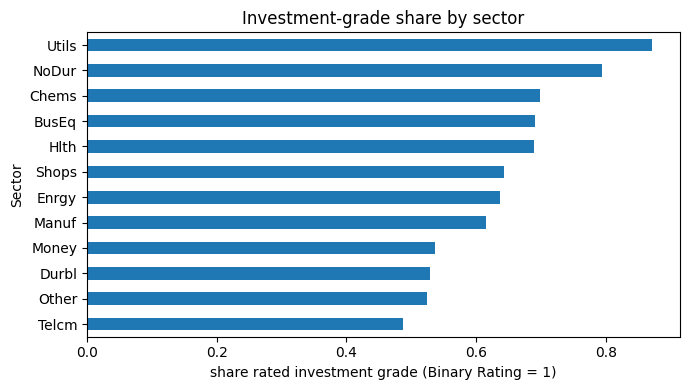

Sector
Telcm    0.487
Other    0.524
Durbl    0.529
Money    0.536
Manuf    0.615
Enrgy    0.636
Shops    0.642
Hlth     0.690
BusEq    0.690
Chems    0.698
NoDur    0.794
Utils    0.871
Name: Binary Rating, dtype: float64

In [7]:
# B1 — investment-grade share by sector
sector_rate = df.groupby("Sector")["Binary Rating"].mean().sort_values()

plt.figure(figsize=(7, 4))
sector_rate.plot(kind="barh")
plt.xlabel("share rated investment grade (Binary Rating = 1)")
plt.title("Investment-grade share by sector")
plt.tight_layout()
plt.show()

sector_rate.round(3)

### B2

**In ONE sentence: what does your figure say about credit risk?**

State something that could be wrong. "There is a relationship" is not a claim.

> Utilities are rated investment grade **87.1%** of the time versus **48.7%** for Telecom — a
> 38-point spread across just 12 sectors — but this could be wrong: A2 showed some sectors are
> dominated by a handful of large, frequently re-rated companies, so the gap might reflect **who
> gets rated repeatedly**, not true sector-level risk.

### B3

**In ONE sentence: what would this change about how you build a model?**

> Sector should stay in the model — the spread is too large to ignore — but B2's confound means
> evaluation needs a **company-level (grouped) train/test split** rather than a random row split,
> or the sector effect will be inflated by the model memorizing a few frequently-rated firms.

---
## Submitting

1. Run the whole notebook from a clean kernel: **Kernel → Restart & Run All**.
2. Check that every answer line has been replaced.
3. Push to your own repository as `IC-02.ipynb`.